In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('Iris.csv')

In [4]:
print("="*60)
print("IRIS DATASET - DATA EXPLORATION")
print("="*60)

print("\n1. FIRST 5 ROWS OF DATASET:")
print(df.head())

IRIS DATASET - DATA EXPLORATION

1. FIRST 5 ROWS OF DATASET:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
print("\n2. DATASET INFORMATION:")
print("-"*40)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:")
print(df.dtypes)

print("\n3. DATASET DESCRIPTION (Statistical Summary):")
print("-"*40)
print(df.describe())

print("\n4. UNIQUE VALUES IN SPECIES COLUMN:")
print("-"*40)
print(f"Species: {df['Species'].unique()}")
print(f"Count per species:\n{df['Species'].value_counts()}")


2. DATASET INFORMATION:
----------------------------------------
Dataset Shape: 150 rows × 6 columns

Column Names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

3. DATASET DESCRIPTION (Statistical Summary):
----------------------------------------
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75

In [6]:
print("\n5. MISSING VALUES CHECK:")
print("-"*40)
missing_values = df.isnull().sum()
print(f"Missing values per column:\n{missing_values}")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("\n✓ No missing values found! Dataset is clean.")
else:
    print("\n✗ Missing values detected. Handling them...")
    # Handle missing values (if any)
    df = df.dropna()  # Remove rows with missing values
    # OR: df = df.fillna(df.mean())  # Fill with mean

# Remove Id column as it's not needed for analysis
df = df.drop('Id', axis=1)
print(f"\nDataset after dropping 'Id' column: {df.shape[1]} features")


5. MISSING VALUES CHECK:
----------------------------------------
Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total missing values: 0

✓ No missing values found! Dataset is clean.

Dataset after dropping 'Id' column: 5 features


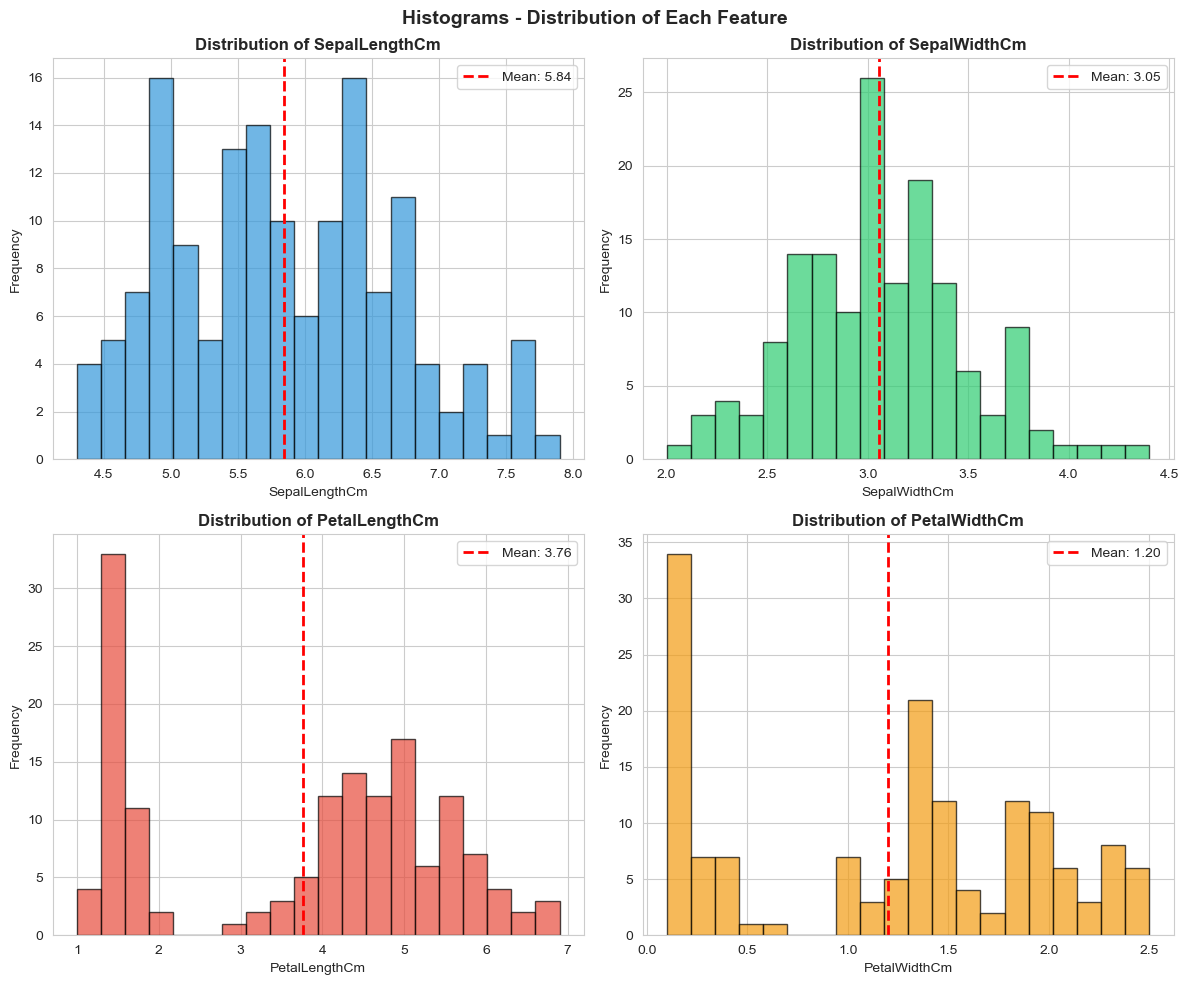

In [7]:
# Create a figure with subplots for histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (feature, color) in enumerate(zip(features, colors)):
    axes[i].hist(df[feature], bins=20, color=color, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df[feature].mean():.2f}')
    axes[i].legend()

plt.suptitle('Histograms - Distribution of Each Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

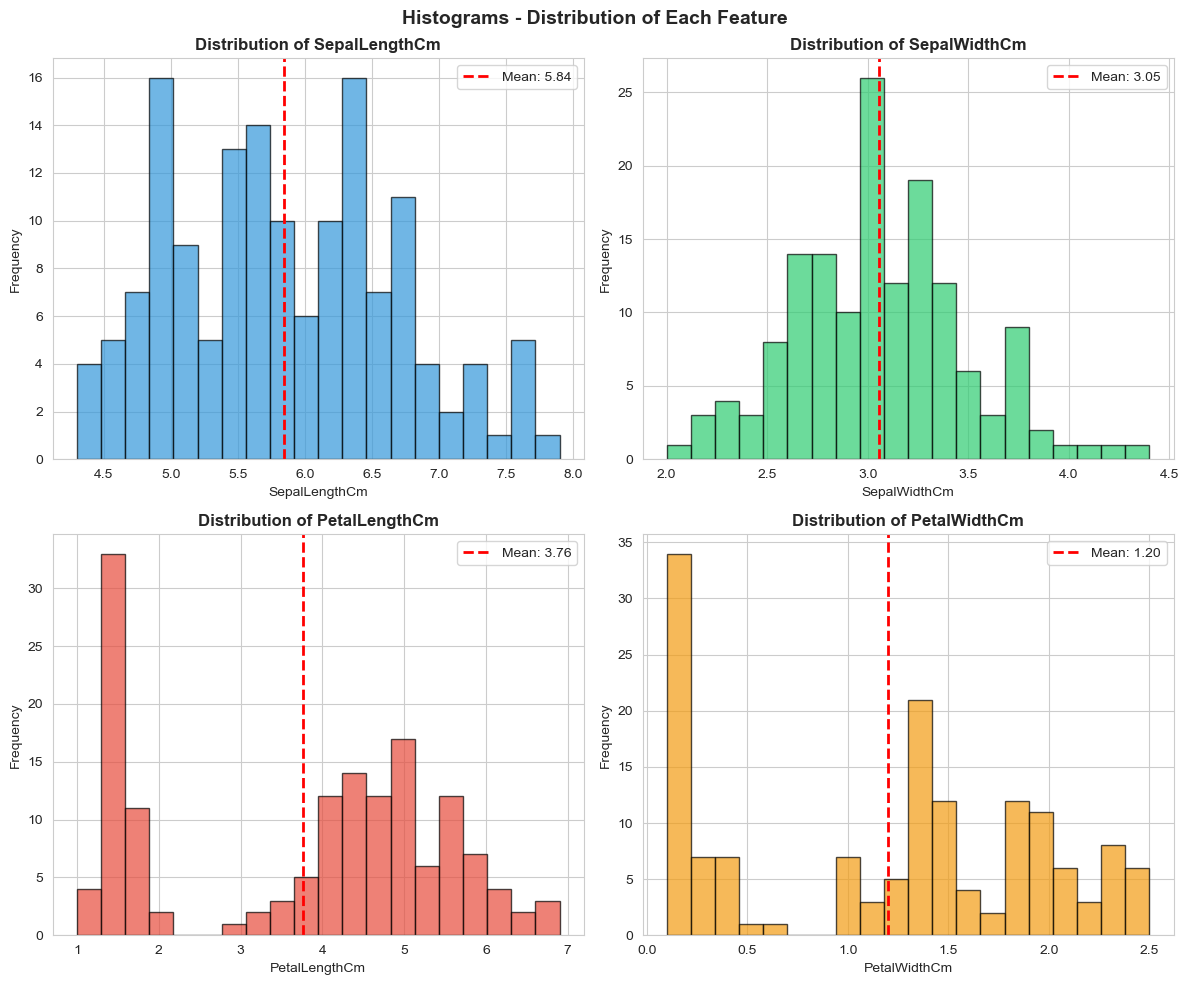

In [8]:
# Create a figure with subplots for histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (feature, color) in enumerate(zip(features, colors)):
    axes[i].hist(df[feature], bins=20, color=color, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df[feature].mean():.2f}')
    axes[i].legend()

plt.suptitle('Histograms - Distribution of Each Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

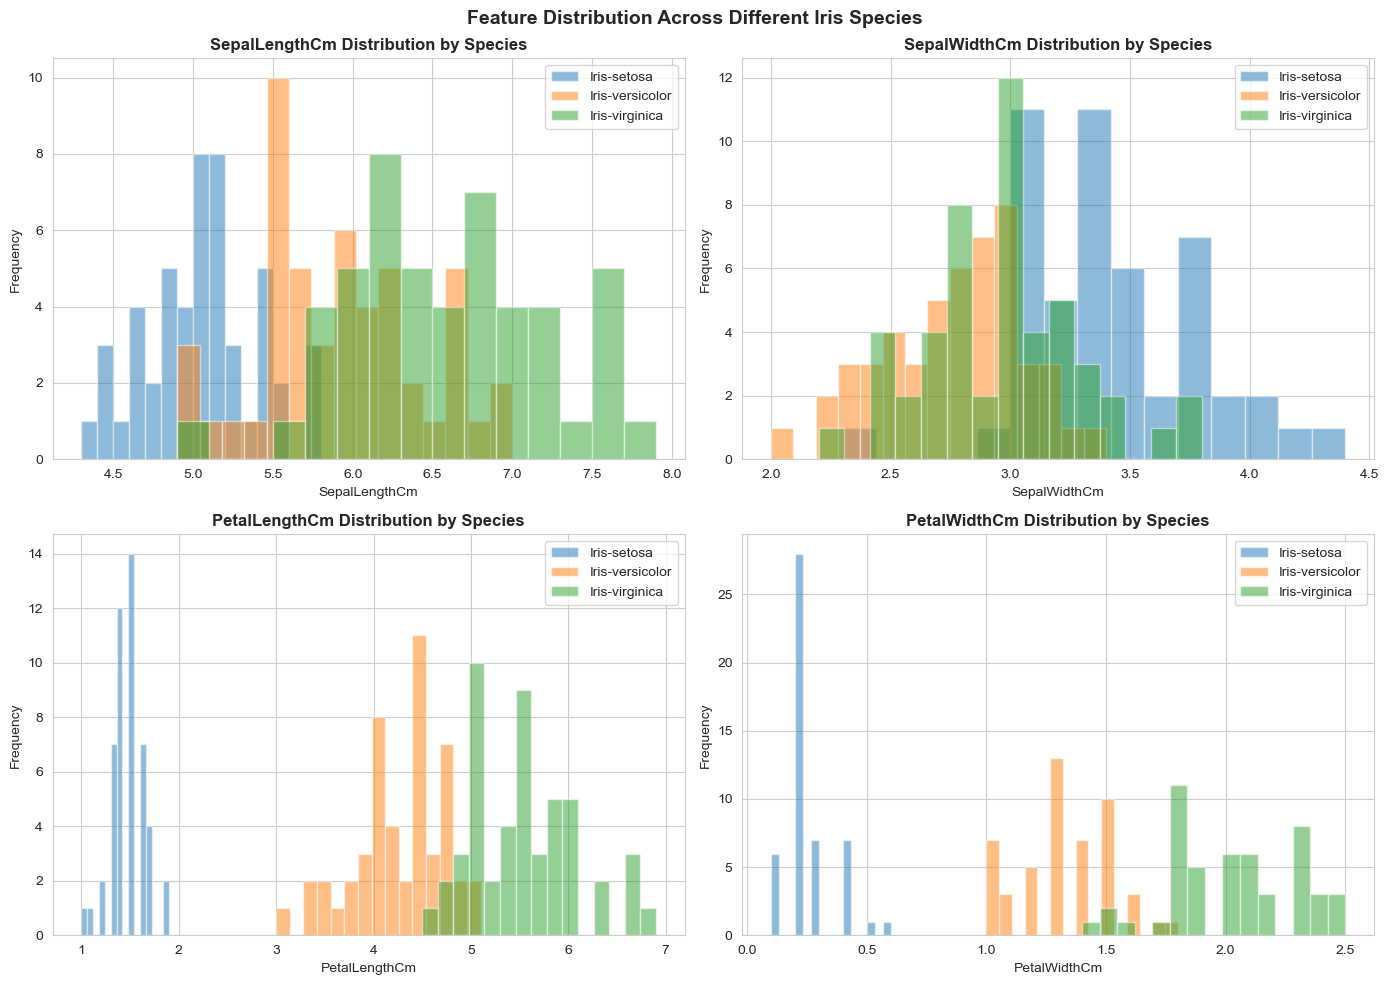

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    for species in df['Species'].unique():
        species_data = df[df['Species'] == species][feature]
        axes[i].hist(species_data, alpha=0.5, label=species, bins=15)
    axes[i].set_title(f'{feature} Distribution by Species', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Feature Distribution Across Different Iris Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

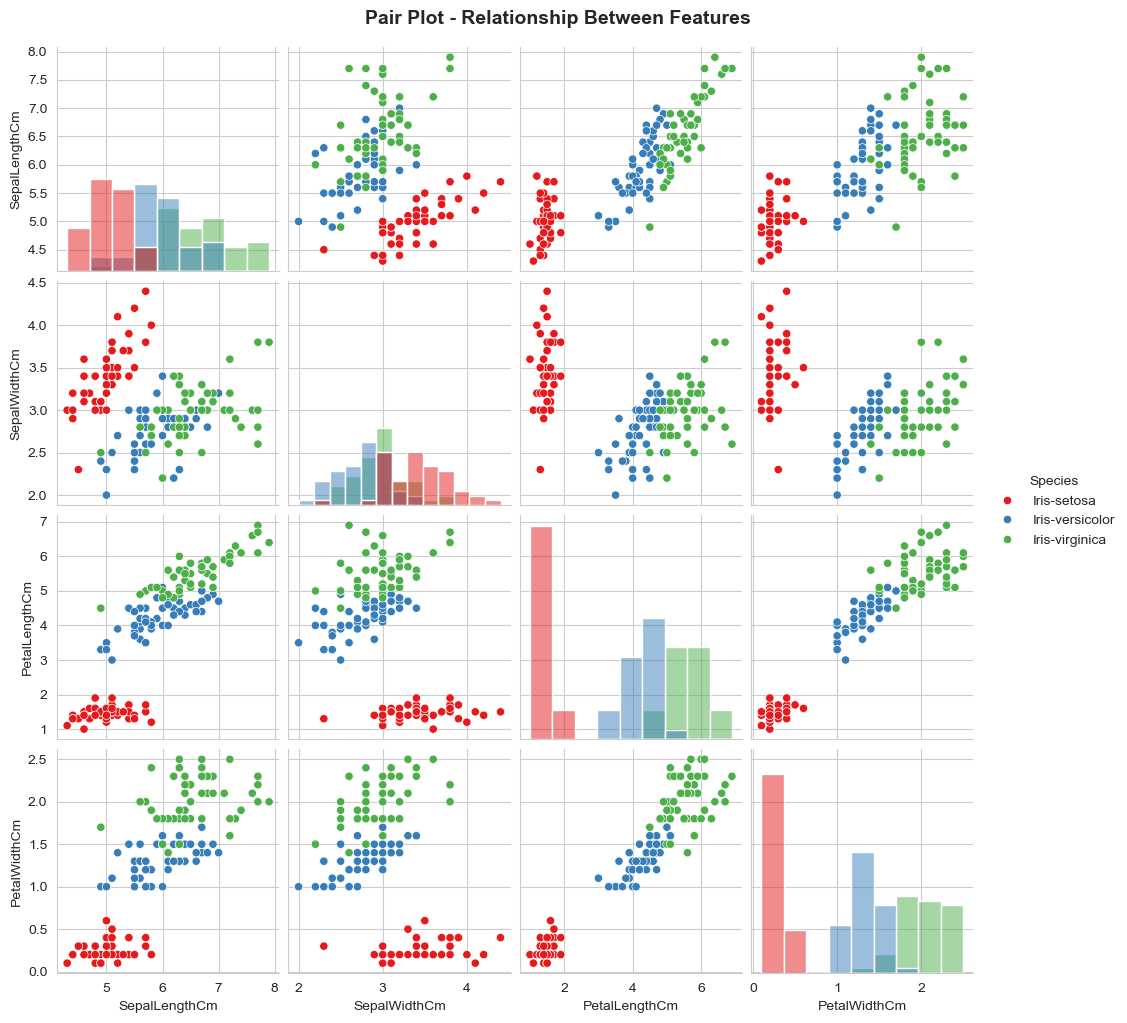

In [10]:
sns.pairplot(df, hue='Species', diag_kind='hist', palette='Set1')
plt.suptitle('Pair Plot - Relationship Between Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

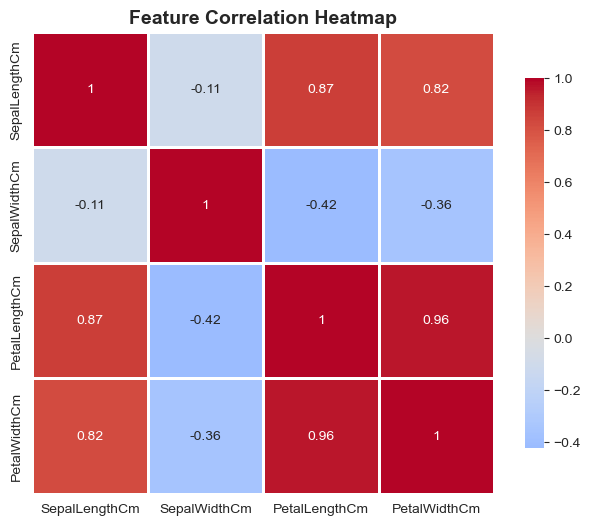

In [11]:
plt.figure(figsize=(8, 6))
correlation = df.drop('Species', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [13]:
print("\n" + "="*60)
print("SUMMARY STATISTICS BY SPECIES")
print("="*60)

for species in df['Species'].unique():
    print(f"\n{species.upper()}:")
    print("-"*40)
    species_data = df[df['Species'] == species].drop('Species', axis=1)
    print(species_data.describe())


SUMMARY STATISTICS BY SPECIES

IRIS-SETOSA:
----------------------------------------
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count       50.00000     50.000000      50.000000      50.00000
mean         5.00600      3.418000       1.464000       0.24400
std          0.35249      0.381024       0.173511       0.10721
min          4.30000      2.300000       1.000000       0.10000
25%          4.80000      3.125000       1.400000       0.20000
50%          5.00000      3.400000       1.500000       0.20000
75%          5.20000      3.675000       1.575000       0.30000
max          5.80000      4.400000       1.900000       0.60000

IRIS-VERSICOLOR:
----------------------------------------
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count      50.000000     50.000000      50.000000     50.000000
mean        5.936000      2.770000       4.260000      1.326000
std         0.516171      0.313798       0.469911      0.197753
min         4.900000   

============================================================
KEY FINDINGS FROM DATA EXPLORATION
============================================================

1. DATASET OVERVIEW:
   • Total samples: 150 flowers
   • Features: 4 measurements (Sepal Length, Sepal Width, Petal Length, Petal Width)
   • Species: 3 types (Setosa, Versicolor, Virginica)
   • Each species: 50 samples

2. DATA QUALITY:
   • No missing values found
   • Dataset is clean and ready for analysis

3. FEATURE INSIGHTS:
   • Petal Length and Petal Width show clear separation between species
   • Sepal measurements have some overlap between species
   • Iris-Setosa is most distinct from other two species

4. CORRELATIONS:
   • Petal Length and Petal Width are highly correlated (≈0.96)
   • Sepal Length and Petal Length are moderately correlated (≈0.87)
   • Sepal Width is weakly correlated with other features

5. OUTLIERS:
   • Few outliers present in Sepal Width measurements
   • Other features show minimal outliers

============================================================
DATA EXPLORATION COMPLETED SUCCESSFULLY!
============================================================
